# ARIMA, SARIMA, Prophet y LSTM para Forecasting

Usamos el dataset de **concentración de CO₂ atmosférico en Mauna Loa**. Tiene tendencia creciente muy clara y estacionalidad anual casi perfecta.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

## 1. Carga y preprocesamiento

El dataset viene en frecuencia **semanal** y tiene algunos valores faltantes

In [ ]:
co2 = sm.datasets.co2.load_pandas().data
print("Forma original (semanal):", co2.shape)
print("Missing values:", co2["co2"].isna().sum())

# Resampling: de semanal a mensual (promedio del mes)
serie = co2["co2"].resample("MS").mean()

# Missing values: interpolación lineal (transición suave, apropiada para una variable física continua)
serie = serie.interpolate(method="linear")

print("Forma después de resampling mensual:", serie.shape)
print("Missing values restantes:", serie.isna().sum())
serie.head()

Forma original (semanal): (2284, 1)
Missing values: 59
Forma después de resampling mensual: (526,)
Missing values restantes: 0


1958-03-01    316.100000
1958-04-01    317.200000
1958-05-01    317.433333
1958-06-01    316.529167
1958-07-01    315.625000
Freq: MS, Name: co2, dtype: float64

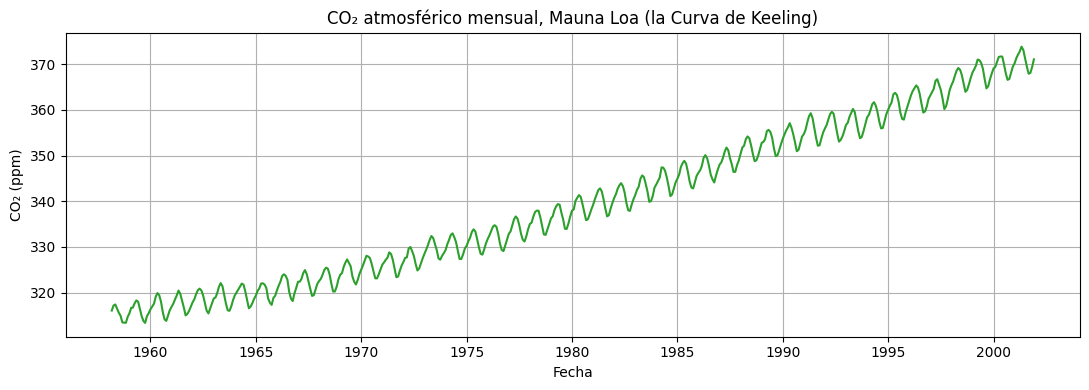

In [ ]:
fig, ax = plt.subplots()
ax.plot(serie.index, serie.values, color="tab:green")
ax.set_title("CO₂ atmosférico mensual, Mauna Loa (la Curva de Keeling)")
ax.set_xlabel("Fecha")
ax.set_ylabel("CO₂ (ppm)")
plt.tight_layout()
plt.show()

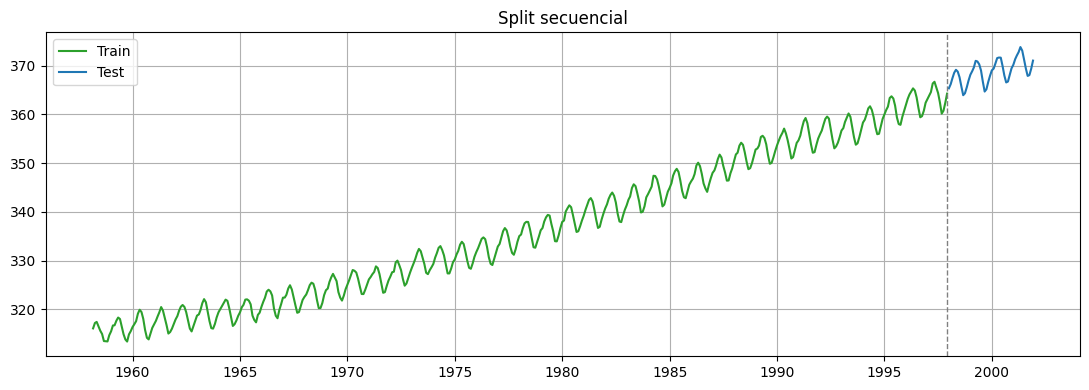

Train: 1958-03-01 a 1997-12-01 (478 obs.)
Test:  1998-01-01 a 2001-12-01 (48 obs.)


In [ ]:
train = serie[serie.index < "1998-01-01"]
test = serie[serie.index >= "1998-01-01"]

fig, ax = plt.subplots()
ax.plot(train.index, train.values, label="Train", color="tab:green")
ax.plot(test.index, test.values, label="Test", color="tab:blue")
ax.axvline(train.index[-1], color="gray", linestyle="--", linewidth=1)
ax.set_title("Split secuencial")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train: {train.index.min().date()} a {train.index.max().date()} ({len(train)} obs.)")
print(f"Test:  {test.index.min().date()} a {test.index.max().date()} ({len(test)} obs.)")

## 2. Repaso rápido: estacionariedad, ACF y PACF

Antes de ajustar cualquier modelo AR/MA, verificamos estacionariedad (test ADF) e identificamos posibles órdenes con ACF/PACF

In [ ]:
def test_adf(x, nombre="serie"):
    resultado = adfuller(x.dropna())
    print(f"--- ADF: {nombre} ---")
    print(f"Estadístico: {resultado[0]:.4f}  |  p-value: {resultado[1]:.4f}")
    print("Conclusión:", "ESTACIONARIA" if resultado[1] < 0.05 else "NO estacionaria", "\n")

test_adf(train, "Serie original (train)")

--- ADF: Serie original (train) ---
Estadístico: 2.1011  |  p-value: 0.9988
Conclusión: NO estacionaria 



In [ ]:
# Diferenciación regular + diferenciación estacional (lag 12)
diff1 = train.diff().dropna()
diff_estacional = diff1.diff(12).dropna()

test_adf(diff1, "Diferenciada (d=1)")
test_adf(diff_estacional, "Diferenciada + estacional (D=1, lag 12)")

--- ADF: Diferenciada (d=1) ---
Estadístico: -4.2011  |  p-value: 0.0007
Conclusión: ESTACIONARIA 

--- ADF: Diferenciada + estacional (D=1, lag 12) ---
Estadístico: -7.8391  |  p-value: 0.0000
Conclusión: ESTACIONARIA 



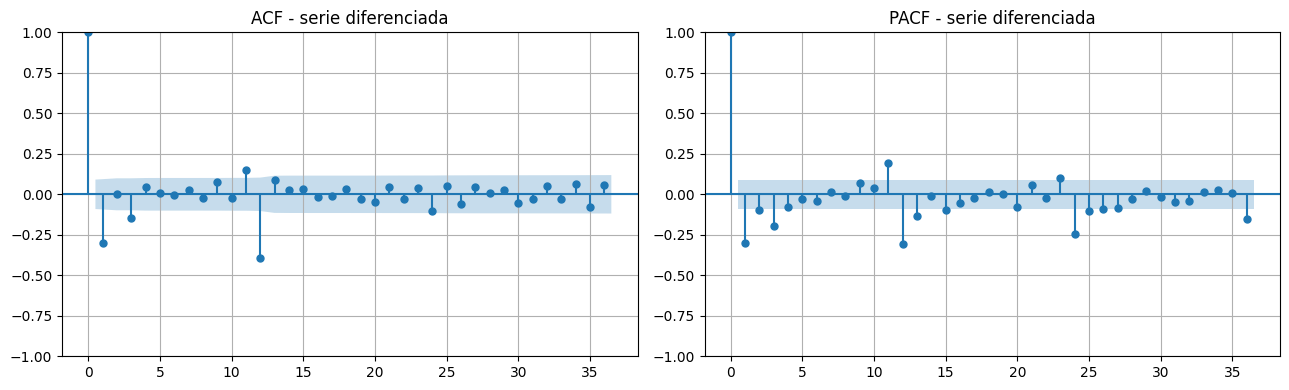

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(diff_estacional, lags=36, ax=axes[0])
axes[0].set_title("ACF - serie diferenciada")
plot_pacf(diff_estacional, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF - serie diferenciada")
plt.tight_layout()
plt.show()

## 3. Modelos AR, MA y ARMA

Ajustamos modelos simples sobre la serie ya diferenciada

In [ ]:
# AR(2) puro: order=(p, d, q) = (2, 0, 0)
modelo_ar = ARIMA(diff_estacional, order=(2, 0, 0)).fit()
print(modelo_ar.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0025      0.013      0.192      0.848      -0.023       0.028
ar.L1         -0.3315      0.045     -7.314      0.000      -0.420      -0.243
ar.L2         -0.0968      0.045     -2.144      0.032      -0.185      -0.008
sigma2         0.1560      0.010     16.410      0.000       0.137       0.175


In [ ]:
# MA(1) puro: order=(0, 0, 1)
modelo_ma = ARIMA(diff_estacional, order=(0, 0, 1)).fit()
print(modelo_ma.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.011      0.204      0.838      -0.019       0.023
ma.L1         -0.4081      0.040    -10.206      0.000      -0.486      -0.330
sigma2         0.1532      0.010     16.019      0.000       0.134       0.172


In [ ]:
print(f"AIC modelo AR(2): {modelo_ar.aic:.2f}")
print(f"AIC modelo MA(1): {modelo_ma.aic:.2f}")

AIC modelo AR(2): 463.93
AIC modelo MA(1): 453.56


## 4. ARIMA sin estacionalidad

Ajustamos ARIMA($p,d,q$) sobre la serie **original** (sin diferenciar a mano, el propio modelo se encarga del parámetro $d$).

In [ ]:
modelo_arima = ARIMA(train, order=(2, 1, 1)).fit()
print(modelo_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                    co2   No. Observations:                  478
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -472.169
Date:                Sat, 26 Sep 2026   AIC                            952.338
Time:                        23:24:56   BIC                            969.008
Sample:                    03-01-1958   HQIC                           958.892
                         - 12-01-1997                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5413      0.029     52.463      0.000       1.484       1.599
ar.L2         -0.8366      0.033    -25.342      0.000      -0.901      -0.772
ma.L1         -0.8129      0.039    -21.061      0.0

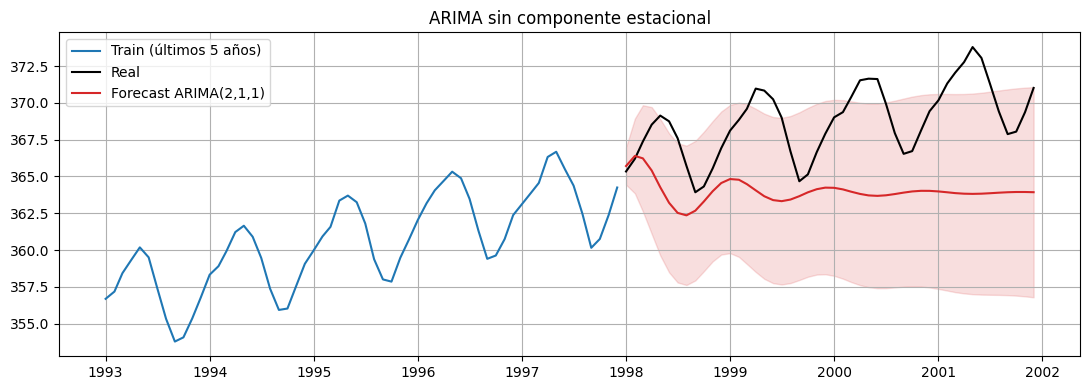

In [ ]:
forecast_arima = modelo_arima.get_forecast(steps=len(test))
pred_arima = forecast_arima.predicted_mean
intervalo_arima = forecast_arima.conf_int()

fig, ax = plt.subplots()
ax.plot(train.index[-60:], train.values[-60:], label="Train (últimos 5 años)")
ax.plot(test.index, test.values, label="Real", color="black")
ax.plot(test.index, pred_arima, label="Forecast ARIMA(2,1,1)", color="tab:red")
ax.fill_between(test.index, intervalo_arima.iloc[:, 0], intervalo_arima.iloc[:, 1], color="tab:red", alpha=0.15)
ax.set_title("ARIMA sin componente estacional")
ax.legend()
plt.tight_layout()
plt.show()

## 5. SARIMA: agregando la estacionalidad

Agregamos el componente estacional $(P,D,Q)_s$ con $s=12$ (estacionalidad anual, datos mensuales).

In [ ]:
modelo_sarima = SARIMAX(train,
                          order=(2, 1, 1),
                          seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print(modelo_sarima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                  478
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -117.603
Date:                            Sat, 26 Sep 2026   AIC                            247.206
Time:                                    23:24:56   BIC                            272.058
Sample:                                03-01-1958   HQIC                           256.988
                                     - 12-01-1997                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3770      0.119      3.176      0.001       0.144       0.610
ar.L2          0.0595      0.072   

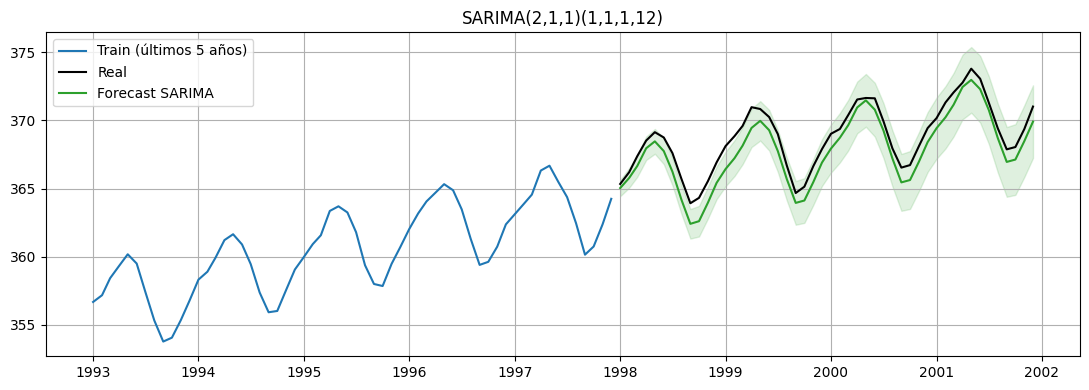

In [ ]:
forecast_sarima = modelo_sarima.get_forecast(steps=len(test))
pred_sarima = forecast_sarima.predicted_mean
intervalo_sarima = forecast_sarima.conf_int()

fig, ax = plt.subplots()
ax.plot(train.index[-60:], train.values[-60:], label="Train (últimos 5 años)")
ax.plot(test.index, test.values, label="Real", color="black")
ax.plot(test.index, pred_sarima, label="Forecast SARIMA", color="tab:green")
ax.fill_between(test.index, intervalo_sarima.iloc[:, 0], intervalo_sarima.iloc[:, 1], color="tab:green", alpha=0.15)
ax.set_title("SARIMA(2,1,1)(1,1,1,12)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Selección automática de órdenes con `auto_arima`

Elegir $(p,d,q)(P,D,Q)_s$ a mano funciona para un ejemplo de clase, pero en la práctica se usa búsqueda automática por AIC.

In [ ]:
import pmdarima as pm

modelo_auto = pm.auto_arima(train,
                              seasonal=True, m=12,
                              stepwise=True,
                              suppress_warnings=True,
                              trace=True)
print(modelo_auto.summary())

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=338.582, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1517.713, Time=0.01 sec


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1007.132, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1519.176, Time=0.01 sec


 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=0.50 sec


 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=475.433, Time=0.48 sec


...

 ARIMA(2,1,1)(1,0,1)[12]             : AIC=290.375, Time=0.51 sec


 ARIMA(1,1,2)(1,0,1)[12]             : AIC=303.206, Time=0.51 sec


 ARIMA(0,1,2)(1,0,1)[12]             : AIC=293.941, Time=0.32 sec


 ARIMA(2,1,0)(1,0,1)[12]             : AIC=302.917, Time=0.36 sec


 ARIMA(2,1,2)(1,0,1)[12]             : AIC=293.473, Time=0.59 sec

Best model:  ARIMA(1,1,1)(1,0,1)[12]          
Total fit time: 46.134 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  478
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -139.881
Date:                            Sat, 26 Sep 2026   AIC                            289.763
Time:                                    23:25:43   BIC                            310.600
Sample:                                03-01-1958   HQIC                           297.956
                                     - 12-01-1997                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

## 7. Prophet

**Prophet** (desarrollado por Meta) toma un enfoque distinto a ARIMA: en vez de modelar la dependencia estadística entre observaciones, descompone la serie directamente en tendencia + estacionalidad + feriados/eventos, ajustando cada componente por separado.

Prophet espera un DataFrame con columnas `ds` (fecha) e `y` (valor)

In [ ]:
from prophet import Prophet

df_prophet = pd.DataFrame({"ds": serie.index, "y": serie.values})
train_prophet = df_prophet[df_prophet["ds"] < "1998-01-01"]
test_prophet = df_prophet[df_prophet["ds"] >= "1998-01-01"]

modelo_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet.fit(train_prophet)

Importing plotly failed. Interactive plots will not work.


23:25:43 - cmdstanpy - INFO - Chain [1] start processing


23:25:43 - cmdstanpy - INFO - Chain [1] done processing


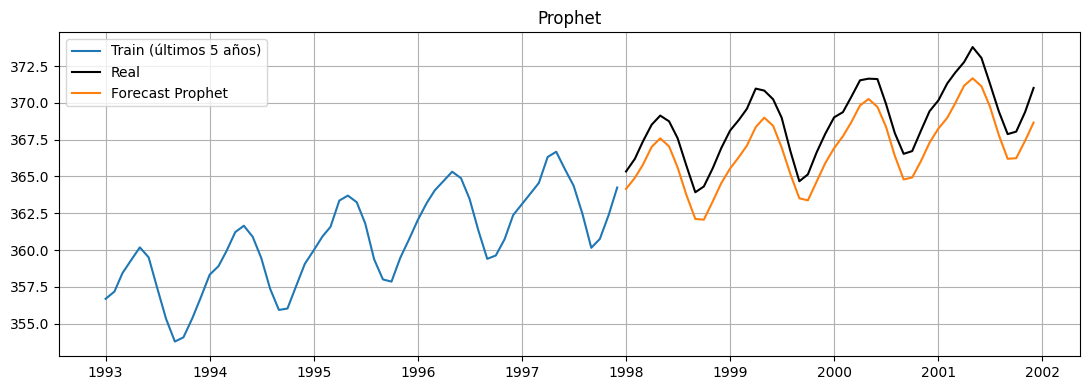

In [ ]:
futuro = modelo_prophet.make_future_dataframe(periods=len(test_prophet), freq="MS")
forecast_prophet = modelo_prophet.predict(futuro)

# Nos quedamos solo con las fechas del periodo de test
pred_prophet = forecast_prophet.set_index("ds").loc[test.index, "yhat"]

fig, ax = plt.subplots()
ax.plot(train.index[-60:], train.values[-60:], label="Train (últimos 5 años)")
ax.plot(test.index, test.values, label="Real", color="black")
ax.plot(test.index, pred_prophet, label="Forecast Prophet", color="tab:orange")
ax.set_title("Prophet")
ax.legend()
plt.tight_layout()
plt.show()

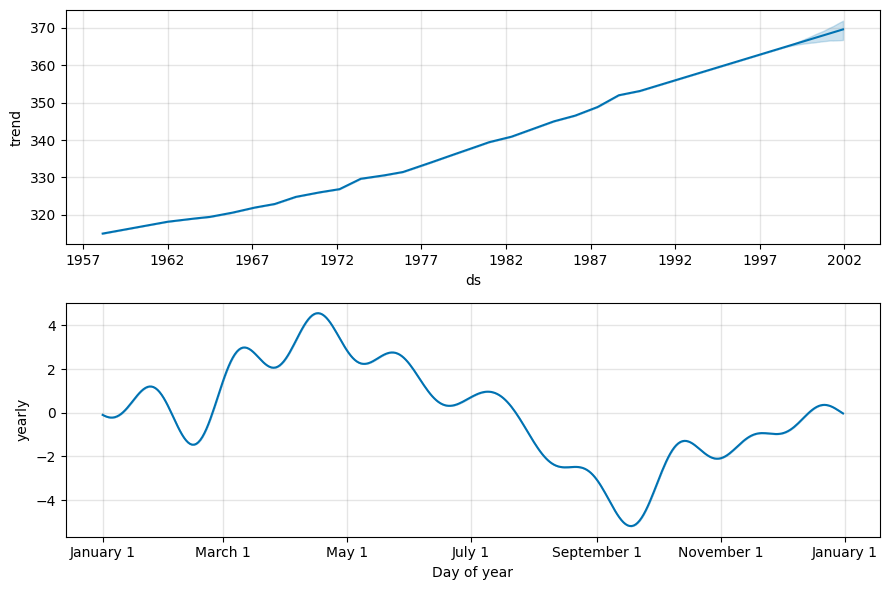

In [ ]:
# Prophet permite inspeccionar los componentes que aprendió por separado
fig = modelo_prophet.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()

# Actividad

Vamos a aplicar ARIMA, SARIMA y Prophet sobre una serie real: las ventas minoristas mensuales de EE.UU. entre 1992 y 2016 (`serie_rs`). El test son los **últimos 24 meses** (`test_rs`) y compararemos con el MAPE (error porcentual medio).

1. Ajuste **ARIMA(p,1,q)** y **SARIMA(p,1,q)(1,1,1,12)** para (p,q) = (1,1) y (2,2) sobre `train_rs`. Pronostique el test, grafique los 4 pronósticos y compare su **MAPE**. ¿Cuál es mejor? ¿Por qué?
2. Pruebe **SARIMA(1,1,1)(1,1,1,s)** con **s = 4, 6 y 12**. Reporte **AIC y MAPE** de cada uno. ¿Qué `s` es mejor y por qué?
3. Ajuste **Prophet** por defecto (`yearly_seasonality=True`) y otro con `yearly_seasonality=False`. Compare su MAPE con el de SARIMA(1,1,1)(1,1,1,12) y grafique los componentes del Prophet por defecto (`plot_components`).
4. Grafique en una misma figura el test real y los pronósticos de **ARIMA(1,1,1)**, **SARIMA(1,1,1)(1,1,1,12)** y **Prophet**. ¿Cuál elegiría? ¿Qué característica de la serie explica la diferencia entre ARIMA y los otros dos?
5. Cuando terminen, avisen para marcarlo como logrado.

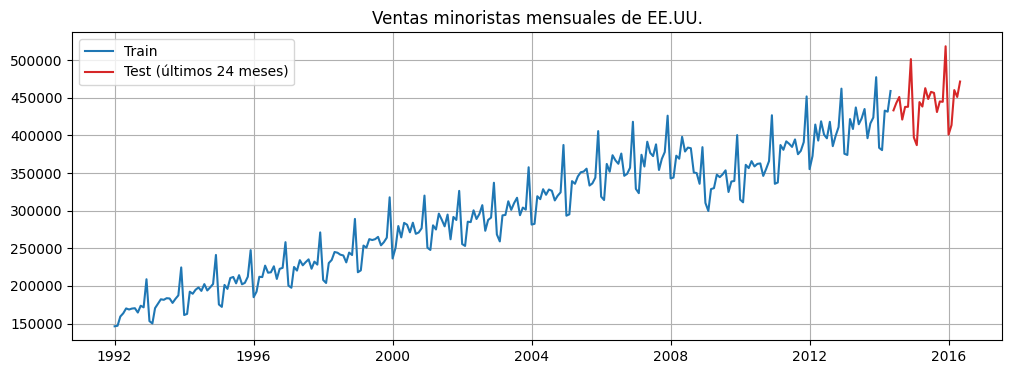

In [ ]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

# Serie real: ventas minoristas mensuales de EE.UU. (1992-2016)
url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_retail_sales.csv"
df_rs = pd.read_csv(url, parse_dates=["ds"]).set_index("ds")
serie_rs = df_rs["y"].asfreq("MS")   # frecuencia mensual (inicio de mes)

# Test: últimos 24 meses
train_rs, test_rs = serie_rs.iloc[:-24], serie_rs.iloc[-24:]

# Formato que exige Prophet (columnas ds e y)
train_prophet_rs = train_rs.reset_index()
train_prophet_rs.columns = ["ds", "y"]

def mape_pct(y_true, y_pred):
    """Error porcentual absoluto medio, en %."""
    return 100 * mean_absolute_percentage_error(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_rs.index, train_rs.values, label="Train")
ax.plot(test_rs.index, test_rs.values, color="tab:red", label="Test (últimos 24 meses)")
ax.set_title("Ventas minoristas mensuales de EE.UU.")
ax.legend()
plt.show()